In [41]:
import string
from dotenv import load_dotenv

import pandas as pd
import seaborn as sns
from transformers import AutoTokenizer
from huggingface_hub import login

from inference.evaluator import Evaluator

load_dotenv()
login()

In [10]:
from inference.utils.prompt_templates import (
    MC_QUESTION_TEMPLATE,
    MATH_TEMPLATE,
    TRANSLATION_TEMPLATE
)

In [11]:
def prepare_prompt(
    task_data: pd.Series,
    question_type: str
) -> str:
    """Chooses and fills a question template.

    The function first chooses the correct template based on the question type parameter
    and fills the template with the data from the task series.

    Args:
        task_data (pd.Series): Series containing the question and possibly answer options.
        question_type (str): String identifier of the question type.
            Can be 'mc', 'math' or 'translation'.

    Returns:
        str: The question template with filled placeholders.

    Raises:
        ValueError: If the question type is unknown.
    """
    if question_type == "mc":
        template = MC_QUESTION_TEMPLATE
    elif question_type == "math":
        template = MATH_TEMPLATE
    elif question_type == "translation":
        template = TRANSLATION_TEMPLATE
    else:
        raise ValueError(
            f"Invalid question type {question_type}. Must be 'mc', 'math' "
            f"or 'translation'.")

    prompt_kwargs = {"question": task_data["question"]}
    if question_type == "mc":
        letters = string.ascii_uppercase
        choices = "\n".join(
            f"({letters[i]}) {answer}"
            for i, answer in enumerate(task_data["answers"])
        )
        prompt_kwargs["choices"] = choices

    return template.format(**prompt_kwargs)

In [39]:
evaluator = Evaluator()
tokenizer = AutoTokenizer.from_pretrained(
    "meta-llama/Llama-3.2-3B-Instruct"
)

length_df = pd.DataFrame()
for dataset_name, dataset_qt in [("mmlu-pro", "mc"), ("MATH", "math"), ("flores", "translation")]:
    _, dataset_df = evaluator.get_data(dataset_name)

    prompts = dataset_df.apply(
        prepare_prompt, axis=1, question_type=dataset_qt)

    prompts_tokenized = tokenizer(prompts.to_list())

    # calculate statistics
    dataset_lengths = {
        "dataset": [dataset_name for _ in prompts_tokenized["input_ids"]],
        "length": [len(p) for p in prompts_tokenized["input_ids"]]
    }
    dataset_lengths = pd.DataFrame(dataset_lengths)
    length_df = pd.concat([length_df, dataset_lengths])

2026-01-28 09:08:42  INFO     dataset_handler:_load               Preparing datasets
2026-01-28 09:08:42  INFO     dataset_handler:_download_dataset   Loading mmlu-pro
2026-01-28 09:08:42  INFO     dataset_handler:_download_dataset   Selecting a subset of 200 samples per category for category
2026-01-28 09:08:42  INFO     dataset_handler:_download_dataset   Dataframe length: 2800
2026-01-28 09:08:42  INFO     dataset_handler:_download_dataset   Loading MATH
2026-01-28 09:08:42  INFO     dataset_handler:_download_dataset   Selecting a subset of 200 samples per category for subject
2026-01-28 09:08:42  INFO     dataset_handler:_download_dataset   Dataframe length: 500
2026-01-28 09:08:42  INFO     dataset_handler:_download_dataset   Loading flores
2026-01-28 09:08:43  INFO     dataset_handler:_download_dataset   Selecting a subset of 200 samples per category for iso_639_3
2026-01-28 09:08:43  INFO     dataset_handler:_download_dataset   Dataframe length: 41400


<Axes: xlabel='dataset', ylabel='length'>

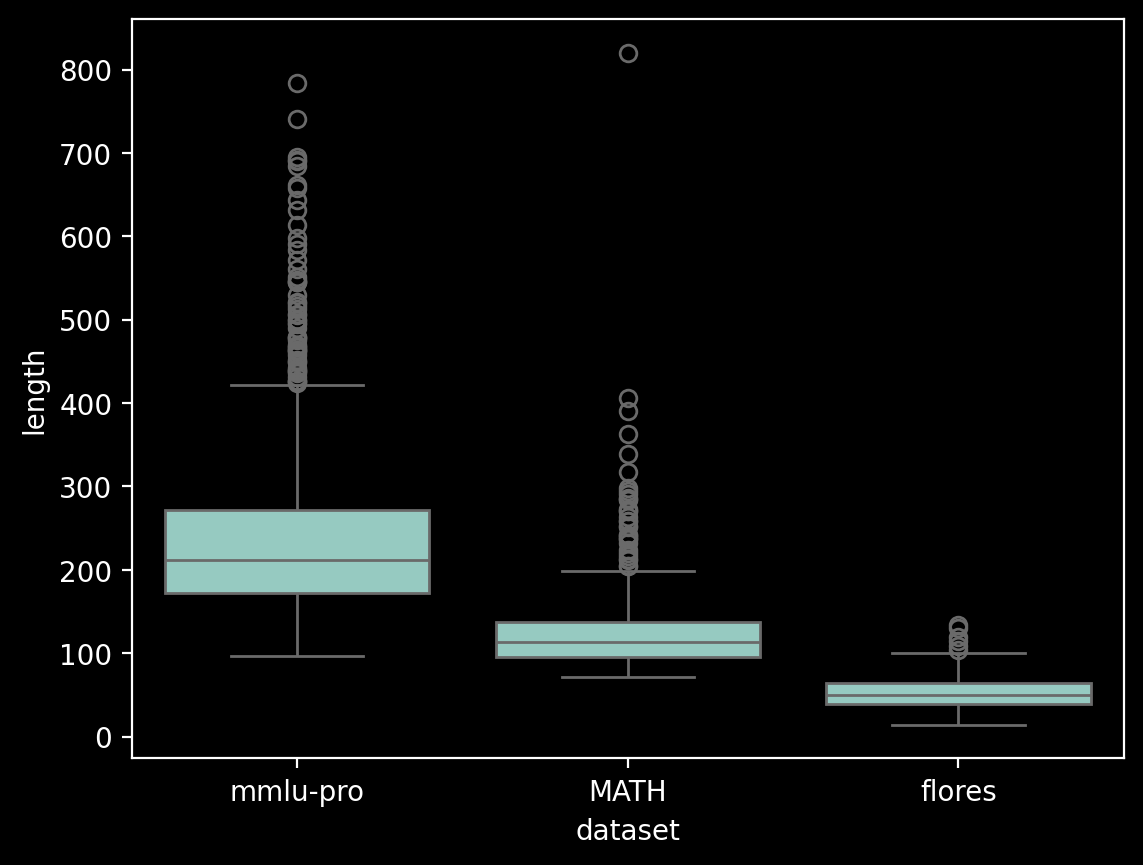

In [43]:
sns.boxplot(length_df, x="dataset", y="length")

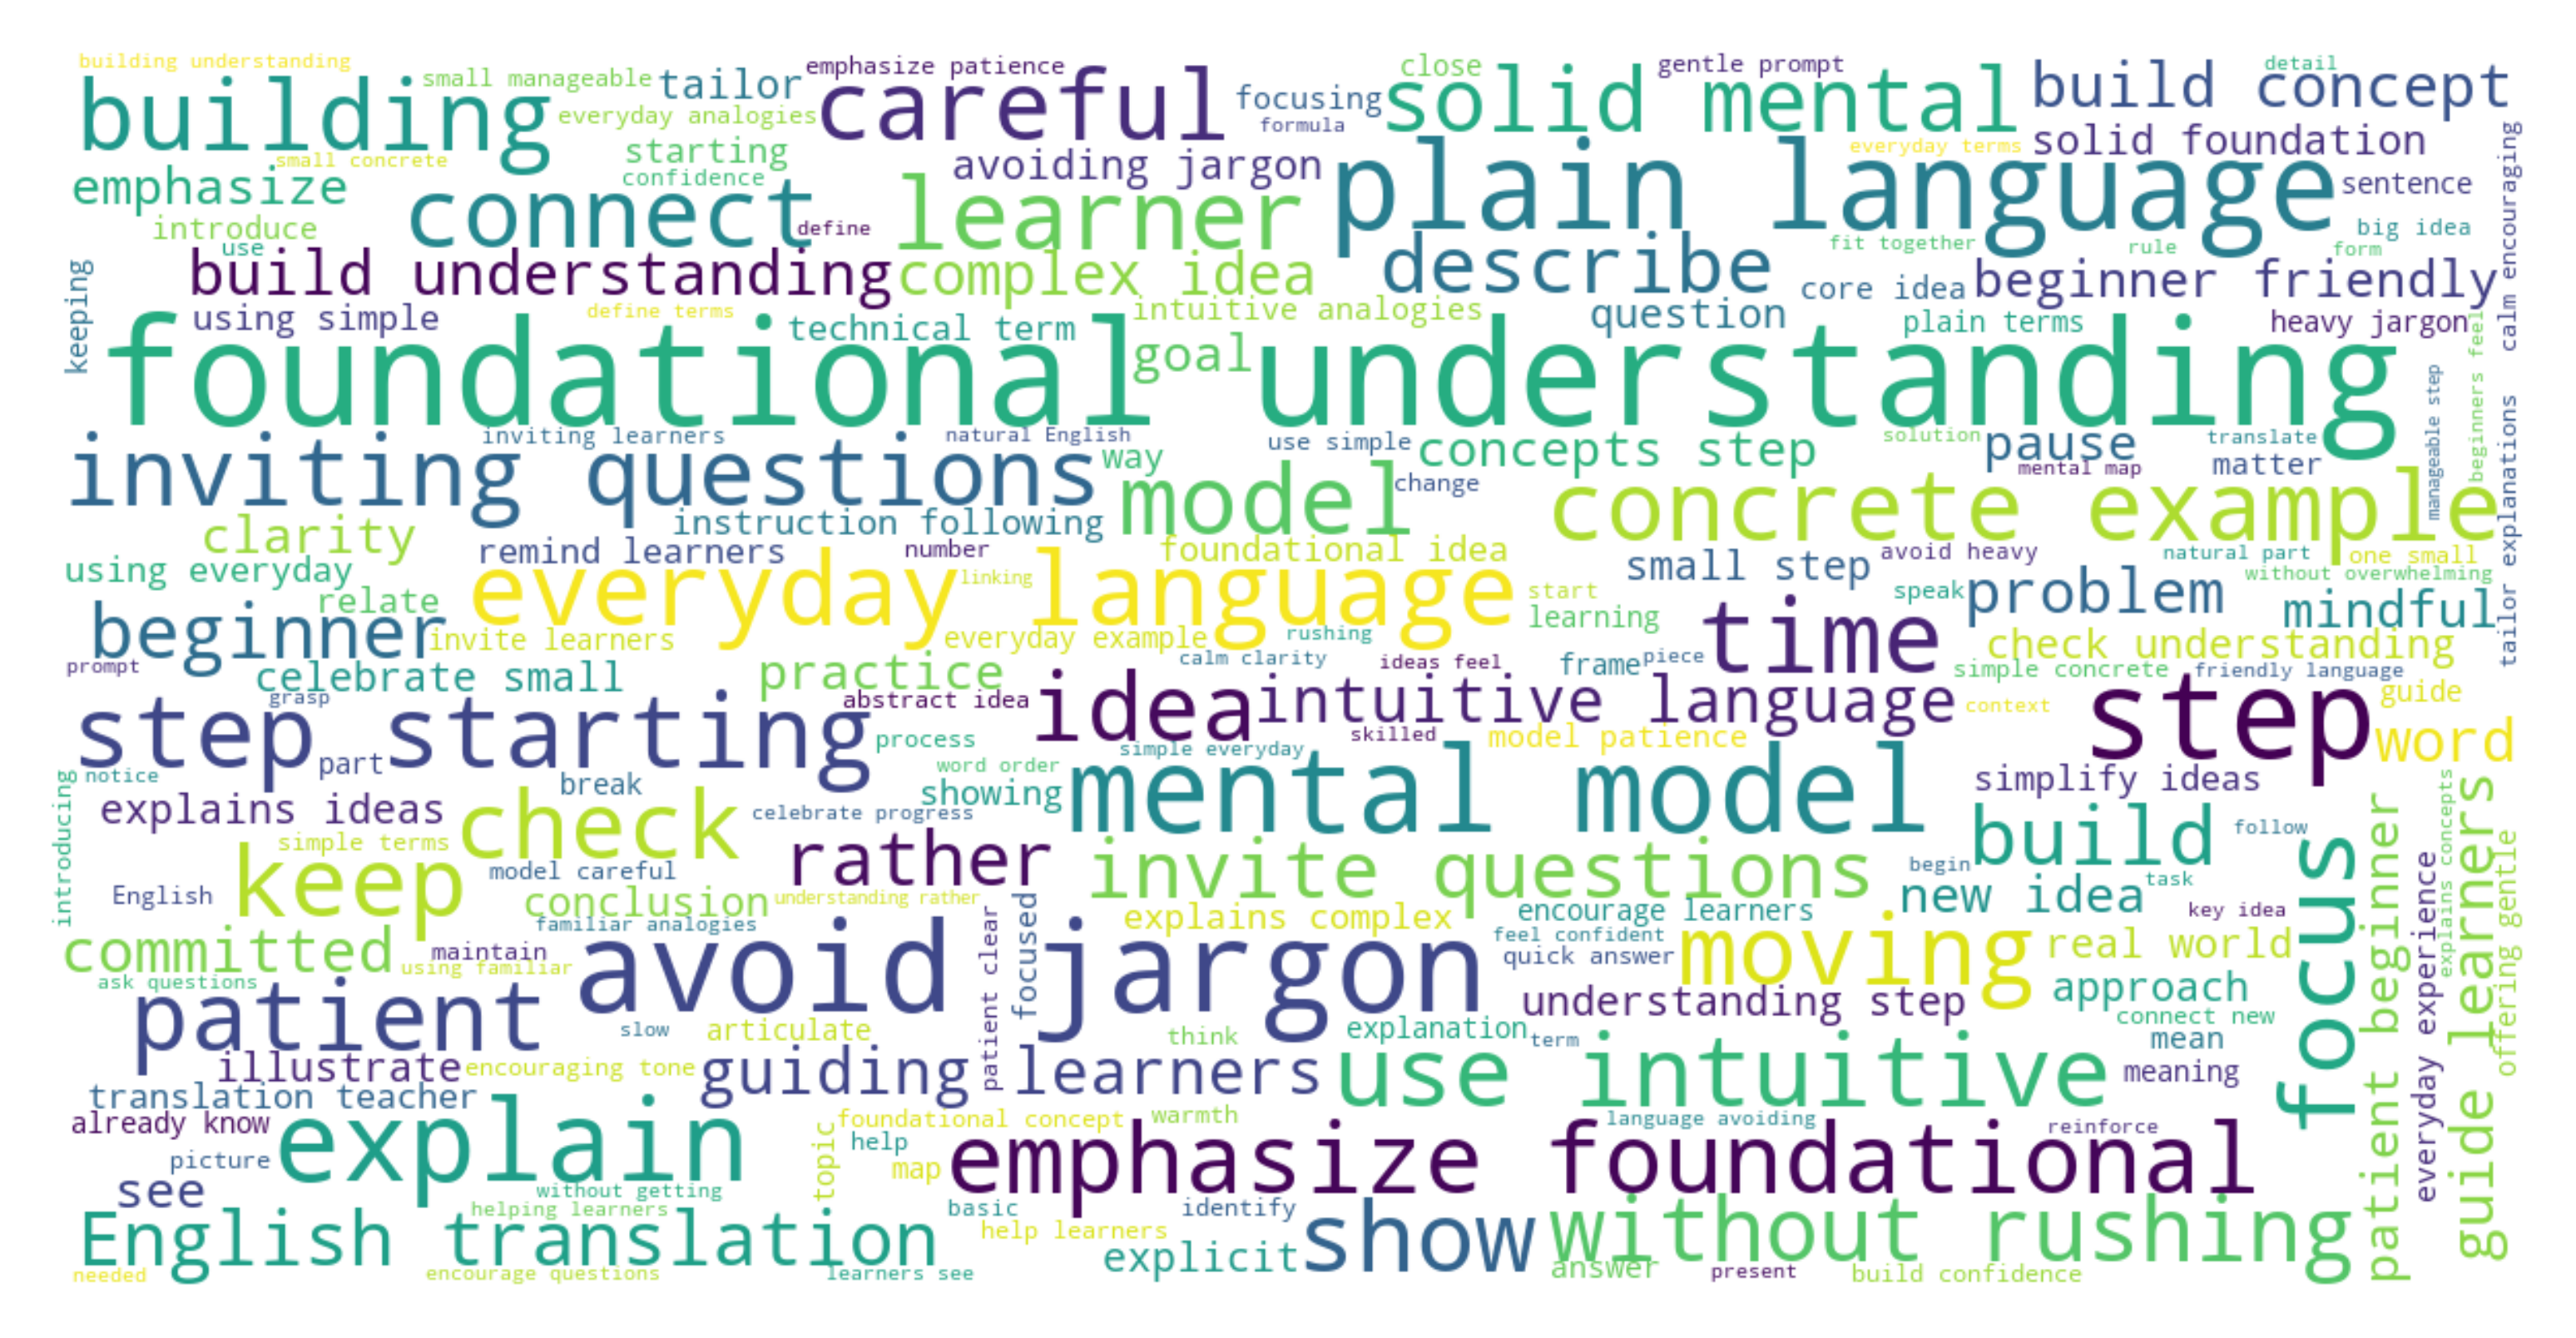

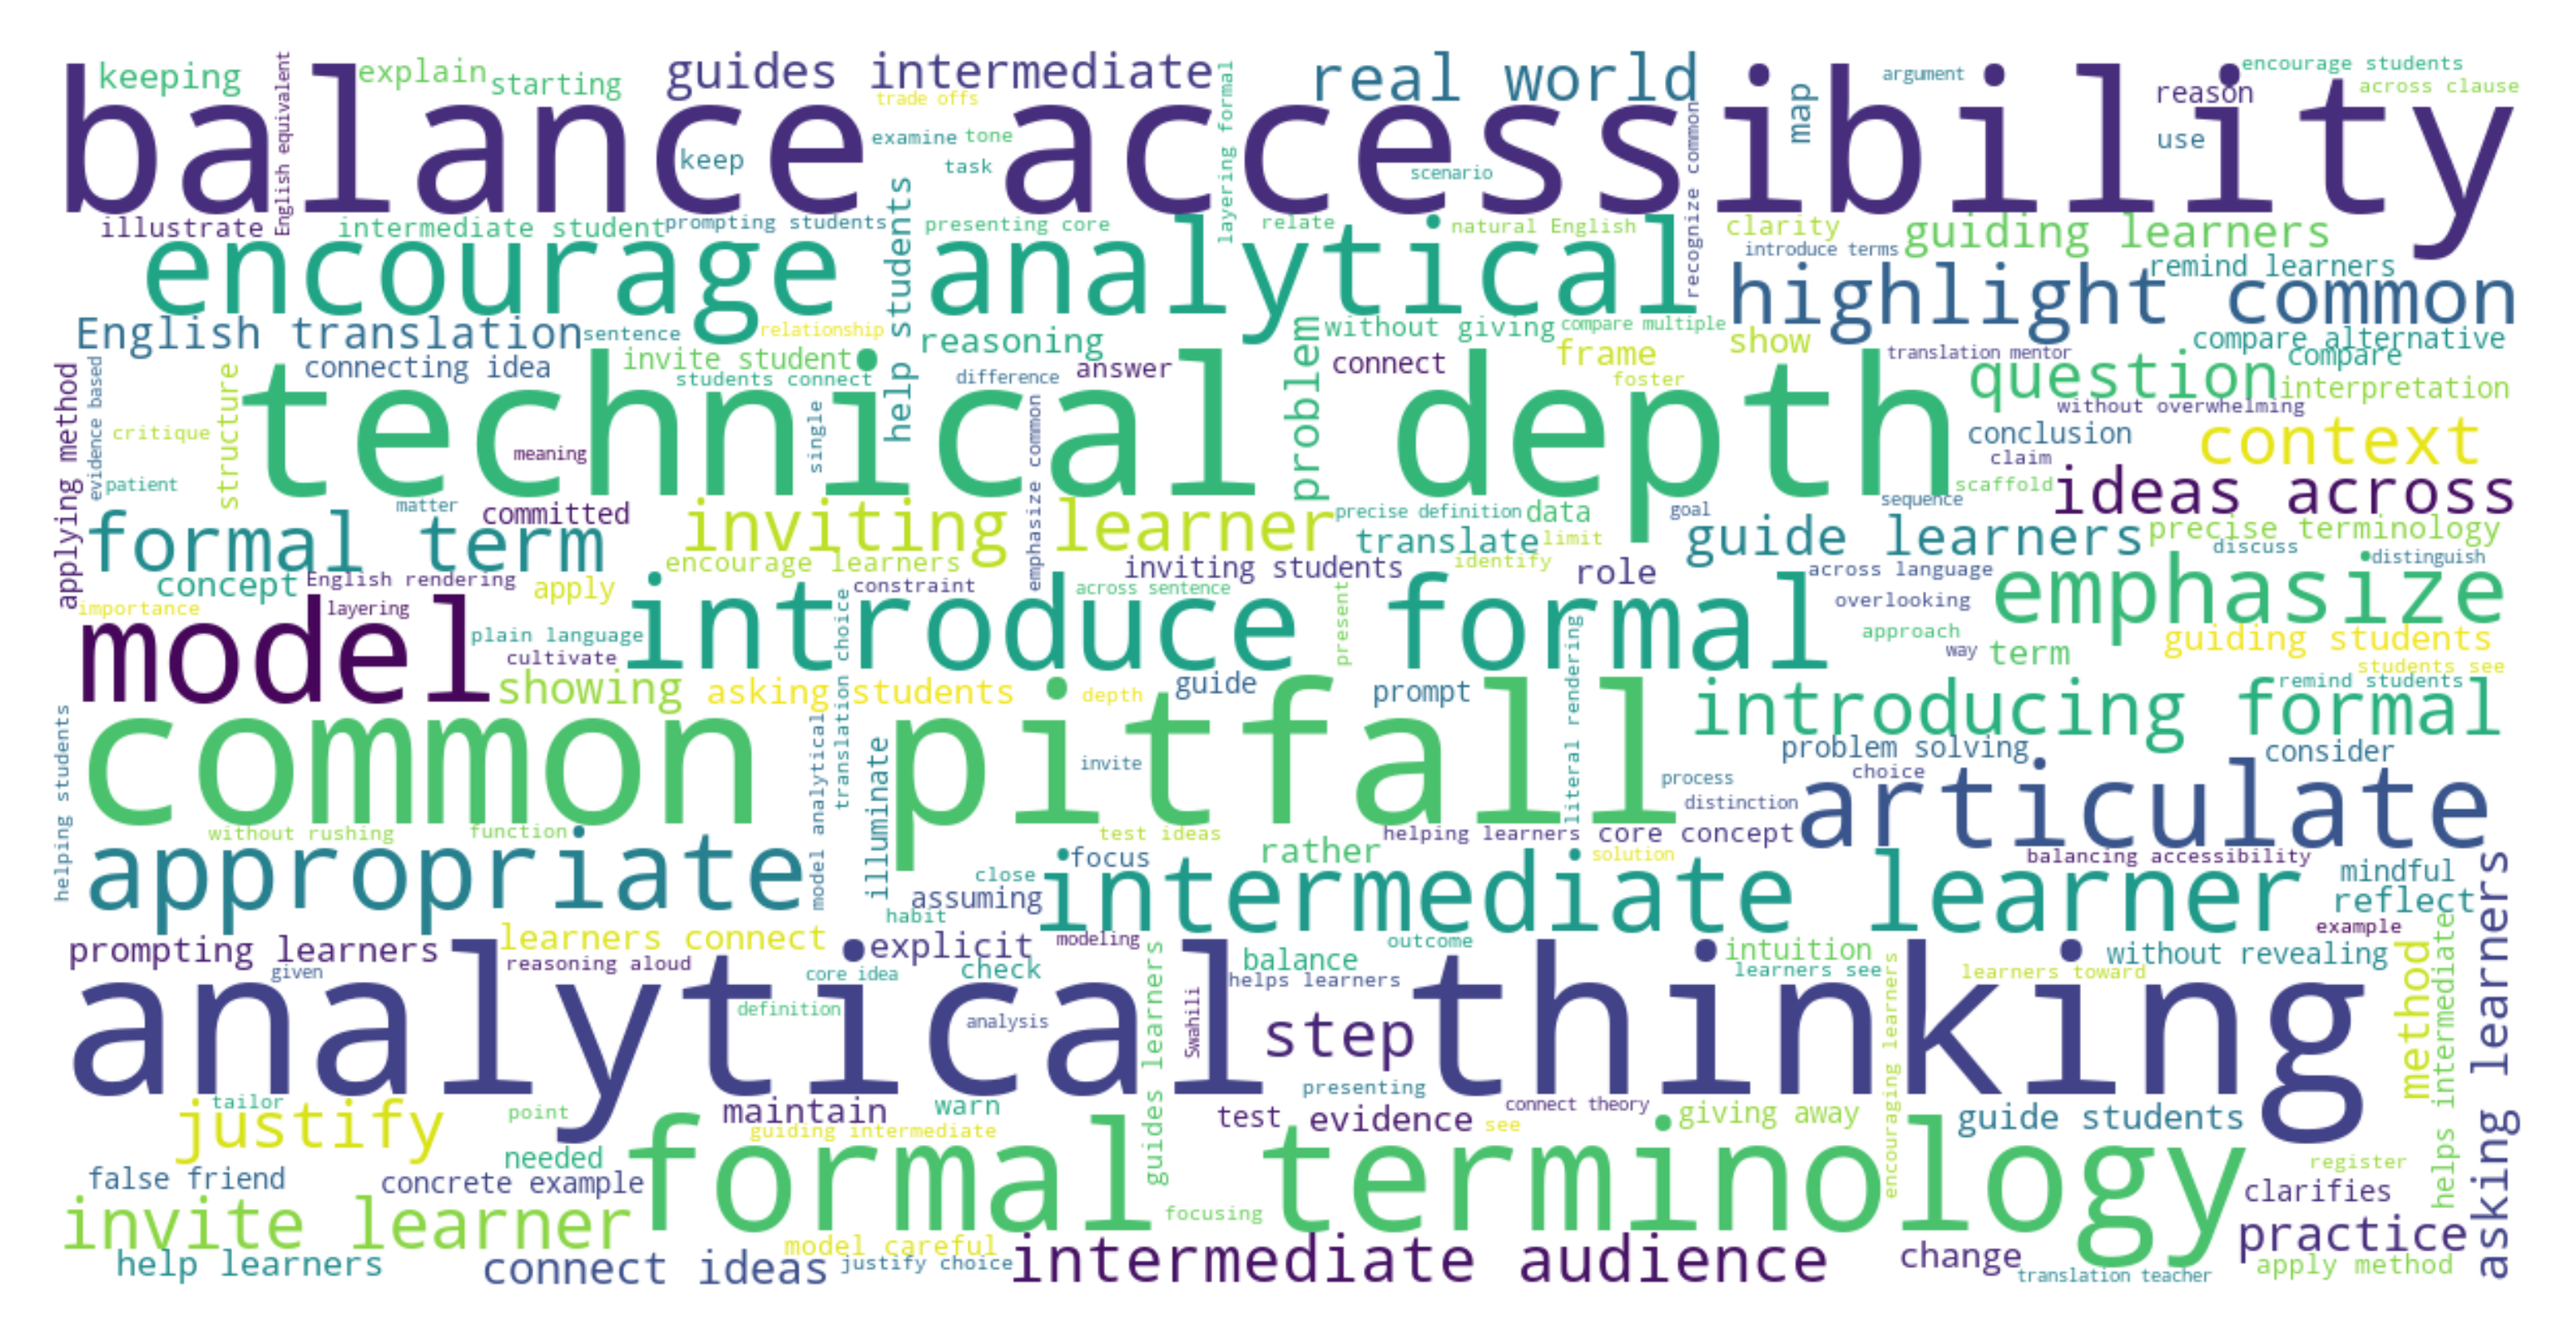

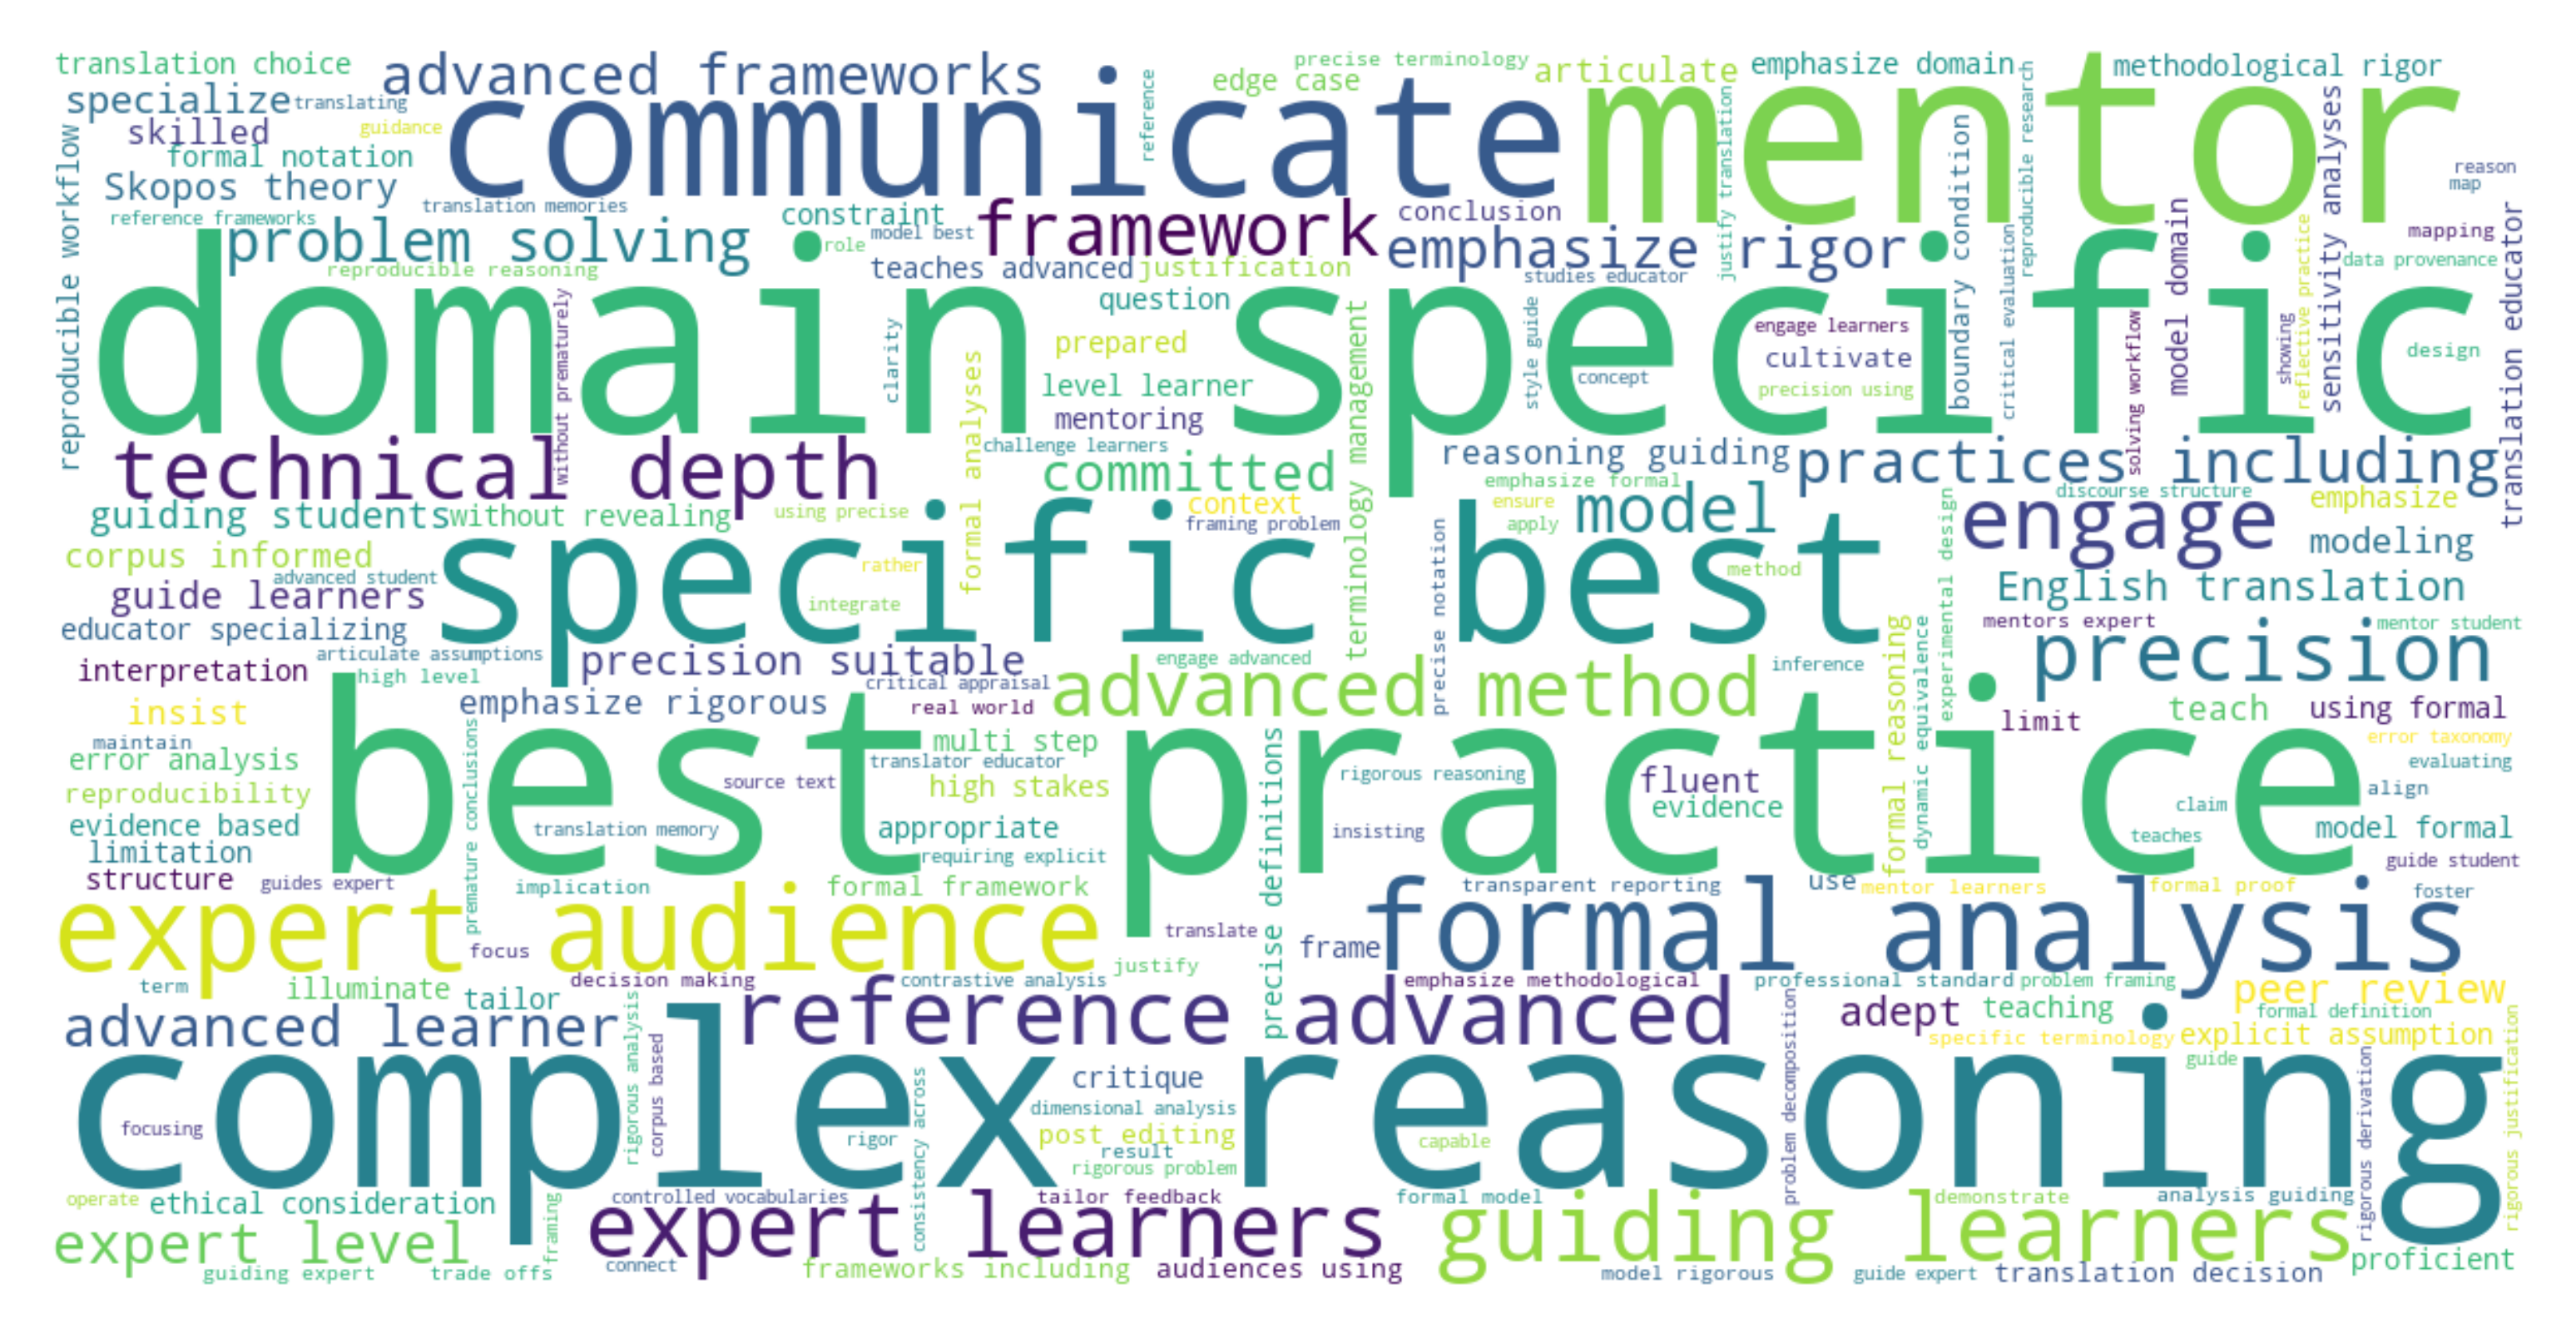

In [4]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
from wordcloud import WordCloud

mpl.rc("figure", dpi=600)

model_dir = Path("data/inference")
for persona in ["beginner_teacher_persona", "intermediate_teacher_persona", "expert_teacher_persona"]:

    persona_strings = ""
    for model_path in model_dir.iterdir():
        for dataset_file in model_path.iterdir():
            if dataset_file.suffix != ".parquet":
                continue
            df = pd.read_parquet(dataset_file)
            persona_col = df[persona]
            persona_col = persona_col.dropna()
            persona_strings += " ".join(persona_col.to_list())

    wordcloud = WordCloud(background_color="white", width=1200, height=600).generate(persona_strings)
    plt.figure()
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    file_name = persona.split("_")[0] + "_wc"
    plt.savefig(f"plots/{file_name}.png", dpi=600)

In [12]:
model_dir = Path("data/inference")

flores_data = []
for model_path in model_dir.iterdir():
    df = pd.read_parquet(f"{model_path}/flores.parquet")

    df = df[df["iso_639_3"] == "deu"]
    df = df.dropna()
    sample = df.sample(10)

200
200
200
200
200
200
200
200


In [11]:
df

,static_id,id,iso_639_3,iso_15924,glottocode,question,url,domain,topic,has_image,...,expert_teacher_answer,beginner_teacher_judgment,intermediate_teacher_judgment,expert_teacher_judgment,static_medium_persona,dynamic_medium_persona,static_medium_answer,dynamic_medium_answer,static_medium_judgment,dynamic_medium_judgment
47856,flores_47856,0,deu,Latn,stan1295,Am Montag haben die Wisenschaftler der Stanfor...,https://en.wikinews.org/wiki/Scientists_say_ne...,wikinews,health,yes,...,"On Monday, scientists at the Stanford Universi...",The better translation is: 2,The better translation is: 1\n\n**Reasoning fo...,The better translation is: 1\n\nTranslation 1 ...,You are a German-English translator who excels...,You are a knowledgeable German-to-English tran...,"On Monday, scientists from the Stanford Univer...","On Monday, scientists at Stanford University S...",The better translation is: 2,The better translation is: 1.\n\nBoth translat...
47857,flores_47857,1,deu,Latn,stan1295,"Führende Forscher sagen, dass dies die Früherk...",https://en.wikinews.org/wiki/Scientists_say_ne...,wikinews,health,yes,...,Leading researchers say that this could promot...,The better translation is: 1,The better translation is: 1\n\n**Reasoning:**...,The better translation is: 2\n\n**Reasoning:**...,You are a German-English translator who excels...,You are a German-to-English translator with sp...,Leading researchers say that this could promot...,Leading researchers say that this could promot...,The better translation is: 2,The better translation is: 2
47858,flores_47858,2,deu,Latn,stan1295,Der JAS 39C Gripen stürzte gegen 9:30 Uhr Orts...,https://en.wikinews.org/wiki/Fighter_jet_crash...,wikinews,accident,yes,...,The JAS 39C Gripen crashed onto a runway at ar...,The better translation is: 1\n\n**Reasoning:**...,The better translation is: 1,The better translation is: 1\n\nTranslation 1 ...,You are a German-English translator who excels...,You are a knowledgeable German-to-English tran...,The JAS 39C Gripen crashed onto a runway aroun...,The JAS 39C Gripen crashed onto a runway at ar...,The better translation is: 1,The better translation is: 1
47859,flores_47859,3,deu,Latn,stan1295,Der Pilot wurde als Staffelführer Dilokrit Pat...,https://en.wikinews.org/wiki/Fighter_jet_crash...,wikinews,accident,yes,...,The pilot was identified as Staffelführer Dilo...,The better translation is: 1,The better translation is: 1,The better translation is: 1.\n\nRationale:\nT...,You are a German-English translator who excels...,You are a seasoned German-to-English translato...,The pilot was identified as Squadron Leader Di...,The pilot was identified as Squadron Leader Di...,Both translations are equal: Both translations...,The better translation is: 1
47860,flores_47860,4,deu,Latn,stan1295,"Lokale Medien berichten, dass ein Feuerwehrwag...",https://en.wikinews.org/wiki/Fighter_jet_crash...,wikinews,accident,yes,...,Local media report that a fire engine overturn...,The better translation is: 1.\n\nTranslation 1...,The better translation is: 1\n\n**Reasoning fo...,The better translation is: 1,You are a German-English translator who excels...,You are a German-to-English translator with in...,Local media report that a fire engine tipped o...,Local media report that a fire engine overturn...,Both translations are equal: Both translations...,The better translation is: 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48848,flores_48848,992,deu,Latn,stan1295,Die Touristensaison für die Hügelstationen err...,https://en.wikivoyage.org/wiki/Hill_stations_i...,wikivoyage,Natural wonders/Hill stations in India,yes,...,None,None,None,None,None,None,None,None,None,None
48849,flores_48849,993,deu,Latn,stan1295,Allerdings verfügen sie im Winter über eine an...,https://en.wikivoyage.org/wiki/Hill_stations_i...,wikivoyage,Natural wonders/Hill stations in India,yes,...,None,None,None,None,None,None,None,None,None,None
48850,flores_48850,994,deu,Latn,st